## Notebook19b

In [1]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds-py/refs/heads/main/funs.py

In [2]:
import numpy as np
import polars as pl

from funs import *
from plotnine import *
from polars import col as c
theme_set(theme_minimal())
pl.Config.set_fmt_str_lengths(1000)

ub = "https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/"

**Research Questions**: Today we explore several themes from your brainstorming:

1. Can TF-IDF help us identify what makes each senator's page unique?
2. Do the words used on Wikipedia pages differ between Republican and Democratic senators?
3. What policy topics are most frequently associated with each party?
4. Are female and male senators described differently on their Wikipedia pages?

### Loading the Data

We will be working with the Wikipedia pages of the 100 current United States Senators. Start by loading the spaCy model and reading in the data.

In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [4]:
docs = pl.read_csv(ub + "data/wiki_senator_class_docs.csv")
docs

doc_id,text
str,str
"""Tommy Tuberville""",""" Thomas Hawley Tuberville (/ˈtʌbərvɪl/; TUH-bərv-il; born September 18, 1954) is an American politician, and retired college football coach and sports broadcaster who is the senior United States senator from Alabama, a seat he has held since 2021. He is a member of the Republican Party. Before entering politics, Tuberville was the head football coach at Auburn University from 1999 to 2008. He was also the head football coach at the University of Mississippi from 1995 to 1998, Texas Tech University from 2010 to 2012, and the University of Cincinnati from 2013 to 2016. Tuberville won five national coach-of-the-year awards (AP, AFCA, Sporting News, Walter Camp, and Bear Bryant) after Auburn's 13–0 season in 2004, in which Auburn won the Southeastern Conference title and the Sugar Bowl, but was left out of the BCS National Championship Game. He earned his 100th career win in 2007. Tuberville is the only Auburn football coach to beat in-state rival Alabama six consecutive times. In 2015, he…"
"""Katie Britt""",""" Katie Elizabeth Boyd Britt (née Boyd; born February 2, 1982) is an American politician and attorney serving since 2023 as the junior United States senator from Alabama. A member of the Republican Party, Britt is the first woman to be elected to the U.S. Senate from Alabama and the youngest Republican woman to be elected to the Senate. She was president and CEO of the Business Council of Alabama from 2019 to 2021, and served as chief of staff for the previous incumbent, Richard Shelby, from 2016 to 2018. Britt was born Katie Elizabeth Boyd on February 2, 1982, to Julian and Debra Boyd in Enterprise, Alabama. During her youth she worked at her family's business. Her family lived near Fort Rucker in Dale County, Alabama. Her father owned a hardware store and later a boat dealership; her mother owned a dance studio. A graduate of Enterprise High School, Britt was a cheerleader and a valedictorian. After graduating in 2000 she studied political science at the University of Alabama. She was…"
"""Lisa Murkowski""",""" Lisa Ann Murkowski (/mərˈkaʊski/ mər-KOW-ski; born May 22, 1957) is an American attorney and politician serving as the senior United States senator from the state of Alaska, having held the seat since 2002. She is the first woman to represent Alaska in the U.S. Congress and is the Senate's second-most senior Republican woman. Murkowski became dean of Alaska's congressional delegation upon Representative Don Young's death. Murkowski is the daughter of former U.S. senator and governor of Alaska Frank Murkowski. She was appointed to the Senate by her father, who resigned his seat in 2002 to become Alaska's governor. Murkowski became the first Alaskan-born member of Congress and completed her father's unexpired Senate term, which ended in January 2005. Before her appointment to the Senate, she had been a member of the Alaska House of Representatives since 1999. Murkowski ran for and won a full term in 2004 with 48% of the vote. After losing the 2010 Republican primary to Tea Party candida…"
"""Dan Sullivan""",""" Daniel Scott Sullivan (born November 13, 1964) is an American politician, attorney, and Marine Corps veteran serving as the junior United States senator from the state of Alaska since 2015. A member of the Republican Party, Sullivan previously served as the commissioner of the Alaska Department of Natural Resources from 2010 to 2013, and as the Alaska Attorney General from 2009 to 2010. Sullivan grew up in a suburb of Cleveland, Ohio and graduated from Culver Academies in Indiana. He studied economics at Harvard University, then earned joint foreign service and Juris Doctor degrees from Georgetown University. He was on active duty for the United States Marine Corps from 1993 to 1997, 2004 to 2006, and in 2009 and 2013. Between 1997 and 1999, he clerked for judges on the United States Court of Appeals for the Ninth Circuit and the Alaska Supreme Court. He worked as 

In [5]:
meta = pl.read_csv(ub + "data/wiki_senator_class.csv")
meta

state,doc_id,page,party
str,str,str,str
"""Alabama""","""Tommy Tuberville""","""Tommy_Tuberville""","""Republican"""
"""Alabama""","""Katie Britt""","""Katie_Britt""","""Republican"""
"""Alaska""","""Lisa Murkowski""","""Lisa_Murkowski""","""Republican"""
"""Alaska""","""Dan Sullivan""","""Dan_Sullivan_(U.S._senator)""","""Republican"""
"""Arizona""","""Mark Kelly""","""Mark_Kelly""","""Democratic"""
…,…,…,…
"""West Virginia""","""Jim Justice""","""Jim_Justice""","""Republican"""
"""Wisconsin""","""Ron Johnson""","""Ron_Johnson""","""Republican"""
"""Wisconsin""","""Tammy Baldwin""","""Tammy_Baldwin""","""Democratic"""


Next, we process the text data through the NLP pipeline. This may take a minute or two to finish.

In [6]:
anno = DSText.process(docs, nlp)
anno

doc_id,sid,tid,token,token_with_ws,lemma,upos,tag,is_alpha,is_stop,is_punct,dep,head_idx,ent_type,ent_iob
str,i64,i64,str,str,str,str,str,bool,bool,bool,str,i64,str,str
"""Tommy Tuberville""",1,1,""" """,""" """,""" ""","""SPACE""","""_SP""",false,false,false,"""dep""",2,"""""","""O"""
"""Tommy Tuberville""",1,2,"""Thomas""","""Thomas ""","""Thomas""","""PROPN""","""NNP""",true,false,false,"""compound""",4,"""PERSON""","""B"""
"""Tommy Tuberville""",1,3,"""Hawley""","""Hawley ""","""Hawley""","""PROPN""","""NNP""",true,false,false,"""compound""",4,"""PERSON""","""I"""
"""Tommy Tuberville""",1,4,"""Tuberville""","""Tuberville ""","""Tuberville""","""PROPN""","""NNP""",true,false,false,"""nsubj""",14,"""PERSON""","""I"""
"""Tommy Tuberville""",1,5,"""(""","""(""","""(""","""PUNCT""","""-LRB-""",false,false,true,"""punct""",4,"""""","""O"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Cynthia Lummis""",184,13,"""Synod""","""Synod ""","""Synod""","""PROPN""","""NNP""",true,false,false,"""appos""",10,"""""","""O"""
"""Cynthia Lummis""",184,14,"""(""","""(""","""(""","""PUNCT""","""-LRB-""",false,false,true,"""punct""",13,"""""","""O"""
"""Cynthia Lummis""",184,15,"""LCMS""","""LCMS""","""LCMS""","""PROPN""","""NNP""",true,false,false,"""appos""",13,"""""","""O"""


Finally, it will be helpful to have the party information merged into the annotation object.

In [7]:
anno = (
    anno
    .join(meta.select(c.doc_id, c.party), on=c.doc_id)
)
anno

doc_id,sid,tid,token,token_with_ws,lemma,upos,tag,is_alpha,is_stop,is_punct,dep,head_idx,ent_type,ent_iob,party
str,i64,i64,str,str,str,str,str,bool,bool,bool,str,i64,str,str,str
"""Tommy Tuberville""",1,1,""" """,""" """,""" ""","""SPACE""","""_SP""",false,false,false,"""dep""",2,"""""","""O""","""Republican"""
"""Tommy Tuberville""",1,2,"""Thomas""","""Thomas ""","""Thomas""","""PROPN""","""NNP""",true,false,false,"""compound""",4,"""PERSON""","""B""","""Republican"""
"""Tommy Tuberville""",1,3,"""Hawley""","""Hawley ""","""Hawley""","""PROPN""","""NNP""",true,false,false,"""compound""",4,"""PERSON""","""I""","""Republican"""
"""Tommy Tuberville""",1,4,"""Tuberville""","""Tuberville ""","""Tuberville""","""PROPN""","""NNP""",true,false,false,"""nsubj""",14,"""PERSON""","""I""","""Republican"""
"""Tommy Tuberville""",1,5,"""(""","""(""","""(""","""PUNCT""","""-LRB-""",false,false,true,"""punct""",4,"""""","""O""","""Republican"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Cynthia Lummis""",184,13,"""Synod""","""Synod ""","""Synod""","""PROPN""","""NNP""",true,false,false,"""appos""",10,"""""","""O""","""Republican"""
"""Cynthia Lummis""",184,14,"""(""","""(""","""(""","""PUNCT""","""-LRB-""",false,false,true,"""punct""",13,"""""","""O""","""Republican"""
"""Cynthia Lummis""",184,15,"""LCMS""","""LCMS""","""LCMS""","""PROPN""","""NNP""",true,false,false,"""appos""",13,"""""","""O""","""Republican"""


### Part 1: What makes each senator's page unique

1. Let's start by understanding the overall content of the dataset. Find the 15 most common nouns across all senator pages.

In [9]:
(
    anno
    .filter(c.upos == "NOUN")
    .group_by([c.doc_id, c.lemma])
    .agg(count = pl.len())
    .sort([c.doc_id, c.count], descending=[False, True])
    .group_by(c.doc_id)
    .head(15)
    .group_by(c.doc_id)
    .agg(top_adj = c.lemma.sort().str.join("; "))
)

doc_id,top_adj
str,str
"""Kirsten Gillibrand""","""%; bill; campaign; district; election; family; gun; law; legislation; member; office; senator; term; vote; year"""
"""Chuck Schumer""","""%; administration; bill; election; government; law; leader; legislation; letter; nominee; people; senator; state; time; vote"""
"""Patty Murray""","""%; administration; area; bill; budget; election; health; letter; member; senator; state; support; term; woman; year"""
"""Maggie Hassan""","""%; bill; campaign; election; governor; law; leader; legislation; majority; nominee; office; position; senator; state; year"""
"""Angela Alsobrooks""","""attorney; bill; campaign; concern; county; covid-19; election; executive; funding; law; member; program; school; state; support"""
…,…
"""Ron Johnson""","""%; administration; bill; budget; campaign; conspiracy; election; government; investigation; issue; people; position; spending; support; vaccine"""
"""Jerry Moran""","""%; attorney; bill; law; legislation; letter; lifetime; majority; member; senator; service; state; time; vote; year"""
"""Joni Ernst""","""bill; campaign; decision; election; government; law; people; response; senator; state; support; trade; vote; weapon; year"""


Look at the output. Do any of these nouns surprise you? Which nouns seem generic to any biography, and which seem specific to senators?

2. Now produce a tfidf dataset, with one document per senator. Set `min_df` to 0.03 (and do so throughout the rest of this notebook) Print out all of the results. How interesting are these?

In [11]:
tfidf = DSText.compute_tfidf(anno, min_df=0.03)
tfidf

doc_id,lemma,tf,tf_norm,df_docs,idf,tfidf
str,str,u32,f64,u32,f64,f64
"""Mark Warner""","""critical""",2,0.000444,38,1.951559,0.000867
"""Adam Schiff""","""anti""",1,0.000244,49,1.703098,0.000416
"""Josh Hawley""","""consider""",2,0.000208,67,1.395613,0.00029
"""Chris Murphy""","""question""",2,0.000411,55,1.589769,0.000653
"""Maria Cantwell""","""voice""",1,0.00027,39,1.926241,0.000521
…,…,…,…,…,…,…
"""Ed Markey""","""night""",1,0.000154,25,2.357024,0.000363
"""Raphael Warnock""","""credit""",1,0.000257,42,1.85392,0.000476
"""Alex Padilla""","""you""",1,0.000375,54,1.607787,0.000602


3. Often all the words are not very telling on their own. Repeat the tfidf construction, but this time use only the nouns. You should see that the results are a (bit) more interesting.

In [13]:
tfidf_noun = (
    anno
    .filter(c.upos == "NOUN")
    .pipe(DSText.compute_tfidf, min_df=0.03)
)
tfidf_noun

doc_id,lemma,tf,tf_norm,df_docs,idf,tfidf
str,str,u32,f64,u32,f64,f64
"""John Cornyn""","""affiliate""",1,0.001272,16,2.781907,0.003539
"""Ted Cruz""","""thousand""",1,0.000498,19,2.619388,0.001303
"""Ruben Gallego""","""career""",1,0.003247,51,1.663877,0.005402
"""Jim Risch""","""chain""",1,0.002646,14,2.90707,0.007691
"""Tom Cotton""","""ceo""",1,0.000703,13,2.976063,0.002091
…,…,…,…,…,…,…
"""Kirsten Gillibrand""","""enforcement""",1,0.000962,50,1.683295,0.001619
"""Dan Sullivan""","""choice""",1,0.00274,31,2.149385,0.005889
"""Mark Kelly""","""problem""",1,0.001149,35,2.031602,0.002335


### Part 2: Do the words used on Wikipedia pages differ between Republican and Democratic senators?

4. Now let's see whether the most common nouns differ by party. To start, find the 10 most common nouns for each party. Print out the results and compare.

In [20]:
(
    anno
    .filter(c.upos == "NOUN")
    .group_by([c.doc_id, c.lemma, c.party])
    .agg(count = pl.len())
    .sort([c.doc_id, c.count], descending=[False, True])
    .group_by(c.party)
    .head(10)
    .group_by(c.party)
    .agg(top_adj = c.lemma.sort().str.join("; "))
)

party,top_adj
str,str
"""Independent""","""%; bill; election; governor; legislation; party; senator; state; vote; year"""
"""Republican""","""%; attorney; ballot; cannabis; court; election; general; law; lawsuit; measure"""
"""Democratic""","""district; election; impeachment; law; manager; member; term; trial; vote; war"""


5. To do this we can create a tfidf matrix again, but set the argument `doc_name` to "party". This in effect changes what we mean by a document in this case.

In [17]:
tfidf_party = DSText.compute_tfidf(anno, min_df=0.03, doc_name="party")
tfidf_party

party,lemma,tf,tf_norm,df_docs,idf,tfidf
str,str,u32,f64,u32,f64,f64
"""Republican""","""Rogers""",7,0.000034,1,1.693147,0.000058
"""Republican""","""diplomatically""",1,0.000005,1,1.693147,0.000008
"""Republican""","""Barton""",1,0.000005,1,1.693147,0.000008
"""Democratic""","""Victoria""",1,0.000005,2,1.287682,0.000007
"""Democratic""","""Yale""",29,0.000153,2,1.287682,0.000198
…,…,…,…,…,…,…
"""Democratic""","""Firearms""",2,0.000011,2,1.287682,0.000014
"""Republican""","""kidnapping""",1,0.000005,1,1.693147,0.000008
"""Independent""","""song""",1,0.00005,3,1.0,0.00005


### Part 3: What policy topics are most frequently associated with each party?

Many of you were curious about which policy areas are most associated with each party. We can investigate this by searching for specific policy-related nouns in the text.

In [19]:
policy_terms = [
    "healthcare", "health", "education", "military", "defense",
    "economy", "tax", "immigration", "abortion", "gun",
    "climate", "environment", "energy", "trade", "budget",
    "veteran", "infrastructure", "housing", "police", "crime",
    "cannabis", "marijuana", "insurance", "welfare", "security"
]

6. Filter the annotation data to just nouns whose lemma is in the policy terms list. Remove the independent party members. Count the number of times each party mentions each lemma. Plot the data with count on the x-axis, term on the y-axis and color indicating the party. Hint: add `scale_color_manual({"Democratic": "blue", "Republican": "red"})`.

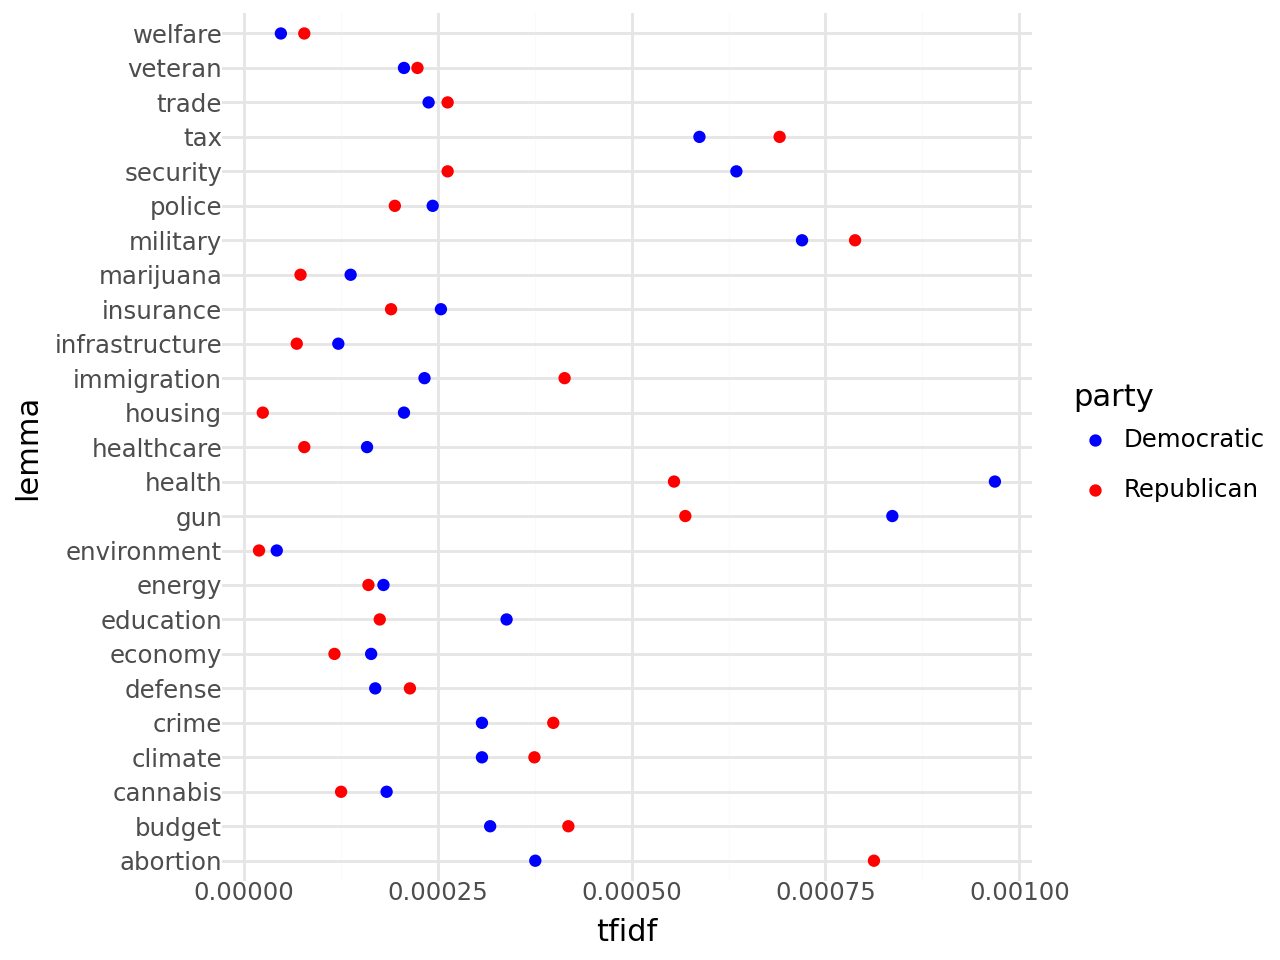

In [26]:
(
    tfidf_party
    .filter(c.lemma.is_in(policy_terms))
    .filter(c.party!= "Independent")
    .pipe(ggplot, aes("tfidf", "lemma"))
    + geom_point(aes(color="party"))
    + scale_colour_manual({"Democratic": "blue", "Republican": "red"})
)

7. The plot above is interesting, but a little difficult to read because of the sorting. And it's actually not easy to sort in that format! Try to pivot the table by party and show a text plot with the Democratic counts on the x-axis and Republican counts on the y-axis.

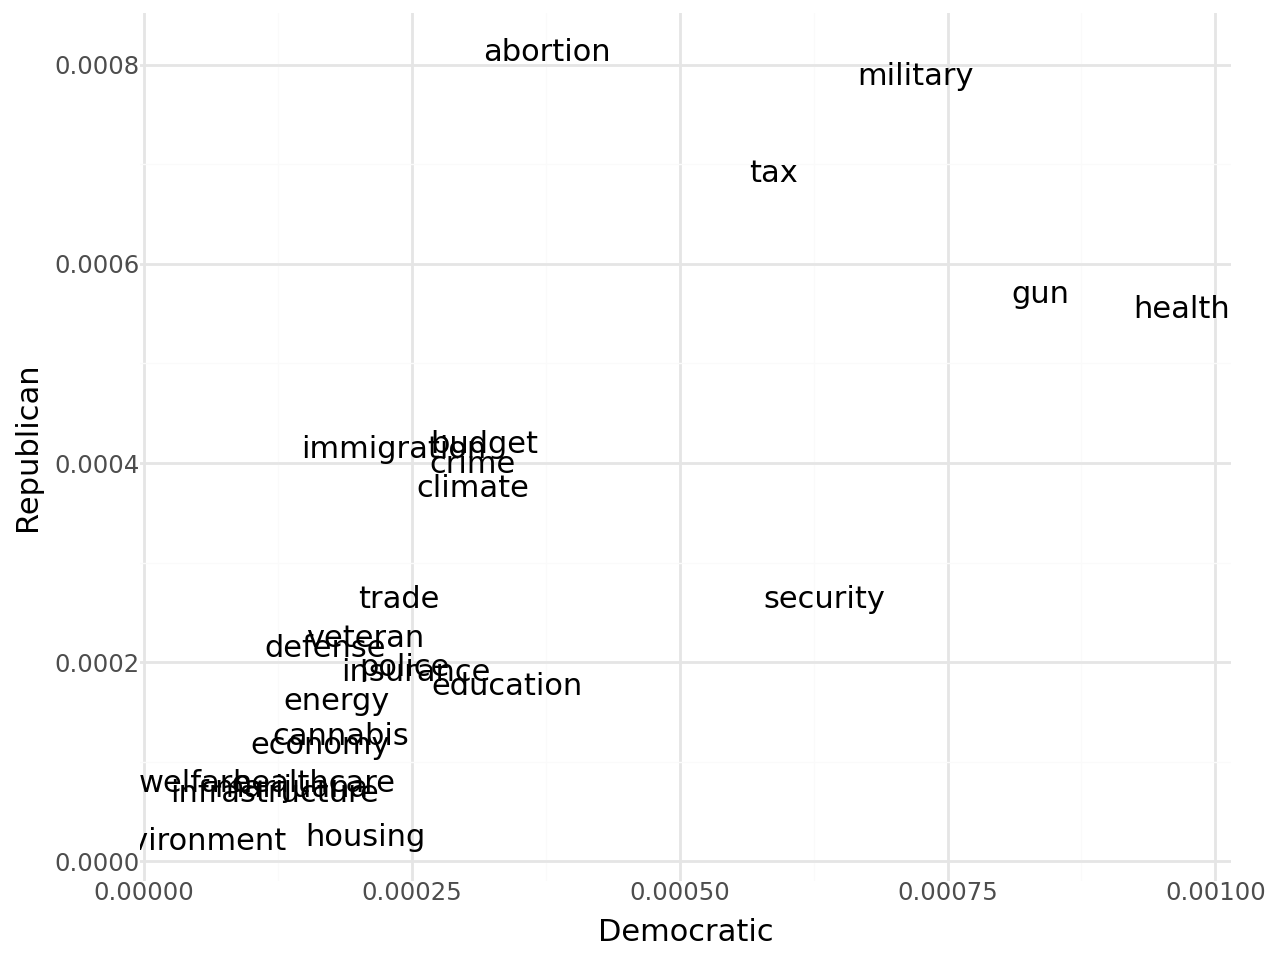

In [31]:
(
    tfidf_party
    .filter(c.lemma.is_in(policy_terms))
    .filter(c.party!= "Independent")
    .pivot(on="party", index="lemma", values="tfidf")
    .pipe(ggplot, aes("Democratic", "Republican"))
    + geom_text(aes(label="lemma"))
)

### Part 4: Gendered Language on Wikipedia

Several of you were interested in whether female and male senators are described differently on their Wikipedia pages. Let's investigate.

8. We don't have a gender marker in our dataset. We could add one manually, but there's a trick that works well for Wikipedia data. To start, filter the annotation data to the first instance of the lemma "she" or "he" in each document. Sort by the lemma and print the data. Take a close look at the results.

9. Using the `pl.when` function, create a dataset `gender_table` that maps each senator's doc_id value to the gender inferred by the above technique.

10. Using the table you made above, join into `anno` and compute the tfidf scores by gender of the highest scoring nouns.

11. Modify the code above to look at the verbs. Note this should be more interesting.

12. Finally, do the same with adjectives.